# Olist E-Commerce Dataset — Exploratory Data Analysis

Quick look at the structured tables that back the SQL pipeline, and the review text that backs the RAG pipeline.

In [1]:
import sqlite3
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

DB_PATH = Path("..") / "data" / "processed" / "olist.db"
conn = sqlite3.connect(DB_PATH)

## Revenue by product category (top 10)

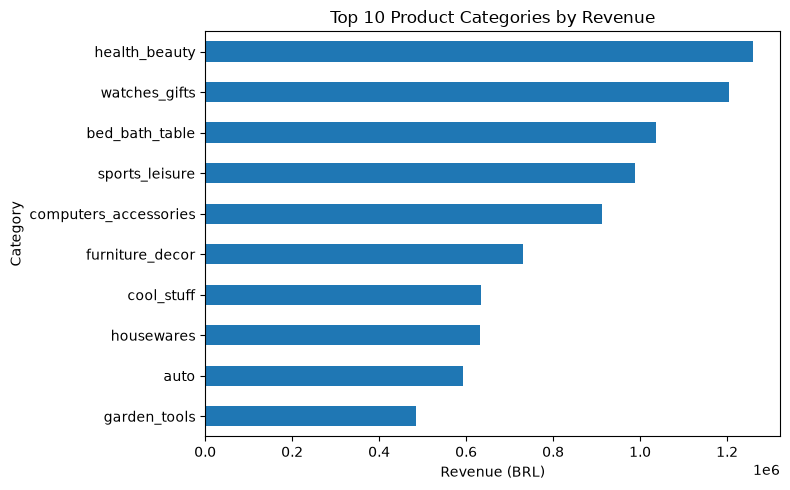

In [2]:
revenue_by_category = pd.read_sql_query(
    """
    SELECT p.product_category_name_english AS category, SUM(oi.price) AS revenue
    FROM order_items oi
    JOIN products p ON p.product_id = oi.product_id
    GROUP BY category
    ORDER BY revenue DESC
    LIMIT 10
    """,
    conn,
)

ax = revenue_by_category.plot.barh(x="category", y="revenue", legend=False, figsize=(8, 5))
ax.set_title("Top 10 Product Categories by Revenue")
ax.set_xlabel("Revenue (BRL)")
ax.set_ylabel("Category")
ax.invert_yaxis()
plt.tight_layout()
plt.savefig("../outputs/figures/revenue_by_category.png", dpi=150)
plt.show()

## Order status distribution

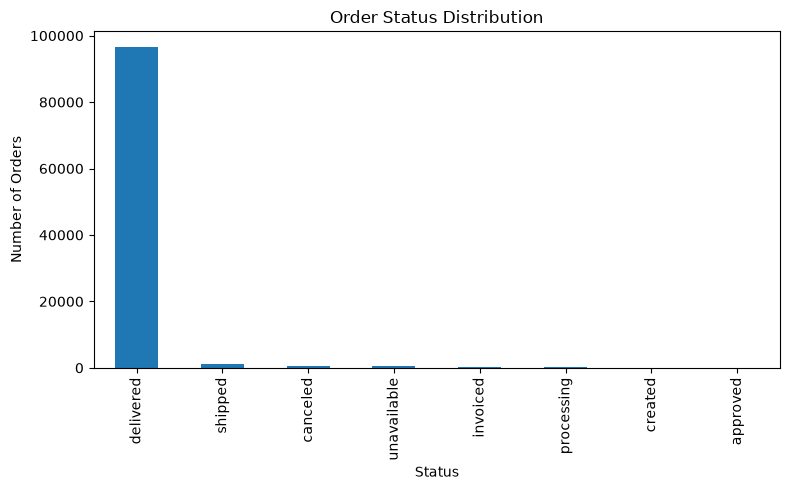

In [3]:
order_status = pd.read_sql_query(
    "SELECT order_status, COUNT(*) AS n FROM orders GROUP BY order_status ORDER BY n DESC", conn
)

ax = order_status.plot.bar(x="order_status", y="n", legend=False, figsize=(8, 5))
ax.set_title("Order Status Distribution")
ax.set_xlabel("Status")
ax.set_ylabel("Number of Orders")
plt.tight_layout()
plt.savefig("../outputs/figures/order_status_distribution.png", dpi=150)
plt.show()

## Review score distribution

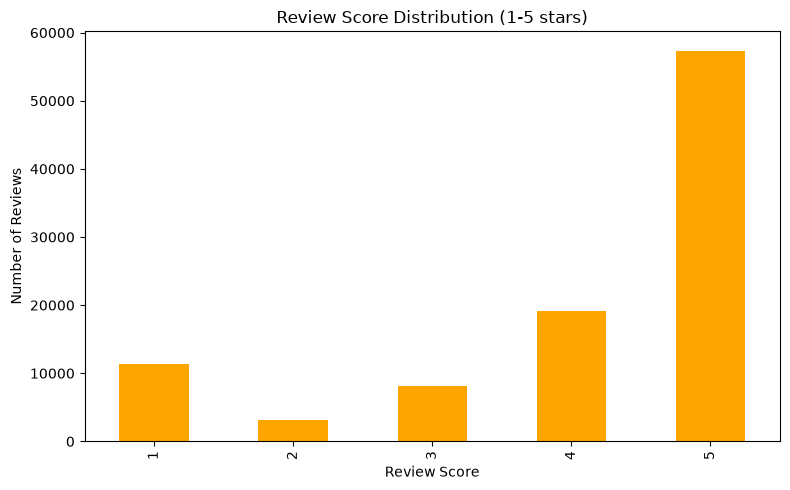

In [4]:
review_scores = pd.read_sql_query(
    "SELECT review_score, COUNT(*) AS n FROM order_reviews GROUP BY review_score ORDER BY review_score", conn
)

ax = review_scores.plot.bar(x="review_score", y="n", legend=False, figsize=(8, 5), color="orange")
ax.set_title("Review Score Distribution (1-5 stars)")
ax.set_xlabel("Review Score")
ax.set_ylabel("Number of Reviews")
plt.tight_layout()
plt.savefig("../outputs/figures/review_score_distribution.png", dpi=150)
plt.show()

## Delivery time: estimated vs actual (delivered orders only)

Average delivery time: 12.1 days
Orders delivered later than estimated: 8.1%


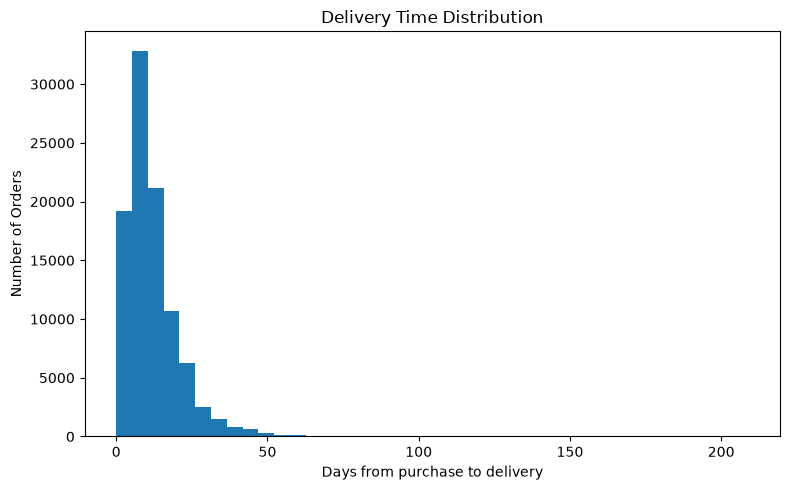

In [5]:
delivery = pd.read_sql_query(
    """
    SELECT order_purchase_timestamp, order_delivered_customer_date, order_estimated_delivery_date
    FROM orders
    WHERE order_status = 'delivered' AND order_delivered_customer_date IS NOT NULL
    """,
    conn,
    parse_dates=["order_purchase_timestamp", "order_delivered_customer_date", "order_estimated_delivery_date"],
)

delivery["delivery_days"] = (delivery["order_delivered_customer_date"] - delivery["order_purchase_timestamp"]).dt.days
delivery["delta_vs_estimate_days"] = (
    delivery["order_estimated_delivery_date"] - delivery["order_delivered_customer_date"]
).dt.days

pct_late = (delivery["delta_vs_estimate_days"] < 0).mean() * 100
print(f"Average delivery time: {delivery['delivery_days'].mean():.1f} days")
print(f"Orders delivered later than estimated: {pct_late:.1f}%")

ax = delivery["delivery_days"].plot.hist(bins=40, figsize=(8, 5))
ax.set_title("Delivery Time Distribution")
ax.set_xlabel("Days from purchase to delivery")
ax.set_ylabel("Number of Orders")
plt.tight_layout()
plt.savefig("../outputs/figures/delivery_time_distribution.png", dpi=150)
plt.show()

## Review text coverage (for the RAG pipeline)

In [6]:
reviews_for_rag = pd.read_csv(Path("..") / "data" / "processed" / "reviews_for_embedding.csv")
print(f"Reviews with non-empty text: {len(reviews_for_rag)}")
reviews_for_rag["product_category"].value_counts().head(10)

Reviews with non-empty text: 42687


product_category
bed_bath_table           4400
health_beauty            3562
sports_leisure           3064
computers_accessories    2823
furniture_decor          2631
watches_gifts            2598
housewares               2496
telephony                1893
auto                     1765
garden_tools             1599
Name: count, dtype: int64